In [1]:
import pyreadr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


#load the smallest file first, fault-free transition data
result = pyreadr.read_r('../data/TEP_FaultFree_Training.rdata')

# pyreade returns a dictionary, let's see what's inside
print(type(result))
print(result.keys())


<class 'collections.OrderedDict'>
odict_keys(['fault_free_training'])


In [2]:
# pull the DataFrame out of the dictionary
df = result['fault_free_training']
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [3]:
#Question  1: how big is the dataset
print("Shape: ", df.shape)
#(rows, columns)

Shape:  (250000, 55)


In [4]:
#Question 2: what does it look like?
df.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [5]:
#Question 3: column types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 55 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   faultNumber    250000 non-null  float64
 1   simulationRun  250000 non-null  float64
 2   sample         250000 non-null  int32  
 3   xmeas_1        250000 non-null  float64
 4   xmeas_2        250000 non-null  float64
 5   xmeas_3        250000 non-null  float64
 6   xmeas_4        250000 non-null  float64
 7   xmeas_5        250000 non-null  float64
 8   xmeas_6        250000 non-null  float64
 9   xmeas_7        250000 non-null  float64
 10  xmeas_8        250000 non-null  float64
 11  xmeas_9        250000 non-null  float64
 12  xmeas_10       250000 non-null  float64
 13  xmeas_11       250000 non-null  float64
 14  xmeas_12       250000 non-null  float64
 15  xmeas_13       250000 non-null  float64
 16  xmeas_14       250000 non-null  float64
 17  xmeas_15       250000 non-nul

In [6]:
# how many unique simulation runs ?
print("Unique runs:", df['simulationRun'].nunique())
print("Run IDS:", sorted(df['simulationRun'].unique()))

Unique runs: 500
Run IDS: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64

In [7]:
# How many samples (snapshot or time step) per run
samples_per_run = df.groupby('simulationRun')['sample'].max()
print(samples_per_run)

simulationRun
1.0      500
2.0      500
3.0      500
4.0      500
5.0      500
        ... 
496.0    500
497.0    500
498.0    500
499.0    500
500.0    500
Name: sample, Length: 500, dtype: int32


In [8]:
# Verify: simulationRuns × samples should ≈ total rows
print("expected rows:", df['simulationRun'].unique() * samples_per_run)

expected rows: simulationRun
1.0         500.0
2.0        1000.0
3.0        1500.0
4.0        2000.0
5.0        2500.0
           ...   
496.0    248000.0
497.0    248500.0
498.0    249000.0
499.0    249500.0
500.0    250000.0
Name: sample, Length: 500, dtype: float64


In [9]:
print("Expected rows:", df['simulationRun'].nunique() * samples_per_run.iloc[0])
print("Actual rows:", len(df))

Expected rows: 250000
Actual rows: 250000


In [10]:
df['simulationRun'] = df['simulationRun'].astype(int)
df['faultNumber'] = df['faultNumber'].astype(int)


In [11]:
print(df[['faultNumber', 'simulationRun', 'sample']].dtypes)

faultNumber      int64
simulationRun    int64
sample           int32
dtype: object


In [12]:
# Grab only SimulatinoRun 1
run1 = df[df['simulationRun'] == 1]
print("Run 1 shape:", run1.shape)
print("Sample range:", run1['sample'].min(), "to", run1['sample'].max())
run1


Run 1 shape: (500, 55)
Sample range: 1 to 500


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0,1,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0,1,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0,1,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0,1,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0,1,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,1,496,0.24602,3651.9,4504.4,9.4721,26.600,42.312,2707.2,...,54.132,23.663,59.588,22.481,38.952,33.489,45.203,49.900,41.057,16.448
496,0,1,497,0.23457,3663.0,4529.5,9.3440,26.872,42.434,2704.1,...,54.028,22.776,60.566,22.237,42.978,38.017,42.637,50.075,41.339,17.435
497,0,1,498,0.23068,3656.4,4493.0,9.2978,26.920,42.536,2700.3,...,54.465,23.158,62.102,21.639,42.483,41.016,46.782,50.098,41.277,18.315
498,0,1,499,0.24263,3632.5,4521.5,9.3915,26.956,42.317,2701.9,...,54.532,23.386,63.164,22.661,39.558,37.892,47.468,50.312,40.557,19.198


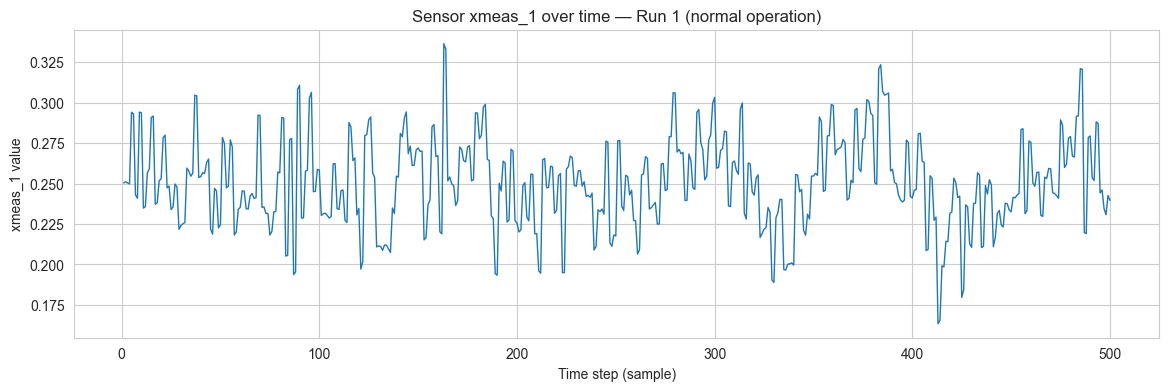

In [13]:
plt.figure(figsize=(14, 4))
plt.plot(run1['sample'], run1['xmeas_1'], linewidth=1.0)
plt.xlabel("Time step (sample)")
plt.ylabel("xmeas_1 value")
plt.title("Sensor xmeas_1 over time — Run 1 (normal operation)")
plt.show()
# this draws a line chart. First argument is x-axis (time steps 1–500), second is y-axis (sensor values).

Reading This Plot:

- The sensor xmeas_1 (which represents the A feed rate — how much raw material A is flowing into the reactor) is bouncing between roughly 0.17 and 0.34, with most values hovering around 0.25. A few things to notice:

- There's no trend. The line doesn't drift upward or downward over time. It wiggles around the same center for all 500 time steps. This is what a stable process looks like — the plant's control system is constantly making tiny adjustments to keep things in range.

- The noise is real, not a bug. Those spikes and dips aren't measurement errors. In a chemical plant, feed rates genuinely fluctuate moment to moment due to valve mechanics, pressure changes, and the control system reacting to other sensors. This natural noise is exactly what makes anomaly detection hard — you need to distinguish "normal wiggle" from "something is actually wrong."
- The range gives us validation bounds. We now know that for xmeas_1, normal values live in roughly [0.17, 0.34]. When we build Faust's validation step (Layer 3, Step 2 in the architecture diagram), we can flag any reading outside this range as suspicious. We'll compute these bounds more precisely with df.describe() soon.

In [14]:
df.describe()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,250000.0,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,0.0,250.500000,250.500000,0.250482,3663.785706,4508.81979,9.347101,26.902196,42.337598,2705.037865,...,53.973668,24.639472,61.298501,22.216644,40.055456,38.098898,46.534295,47.958591,41.104304,18.118706
std,0.0,144.337567,144.337567,0.030873,34.006357,39.21542,0.085721,0.211485,0.218513,7.525596,...,0.469663,3.037743,1.243805,0.530156,1.526751,2.965266,2.351304,2.716520,0.540817,1.463678
min,0.0,1.000000,1.000000,0.122450,3511.800000,4336.90000,8.972700,25.951000,41.394000,2672.300000,...,52.095000,11.977000,55.961000,19.749000,33.389000,25.959000,36.937000,36.641000,38.586000,11.705000
25%,0.0,125.750000,125.750000,0.229770,3640.800000,4482.40000,9.289300,26.758000,42.188000,2700.100000,...,53.657000,22.602000,60.453000,21.864000,39.021000,36.081000,44.931000,46.265000,40.740000,17.130000
50%,0.0,250.500000,250.500000,0.250510,3663.700000,4508.80000,9.347100,26.902000,42.338000,2705.000000,...,53.974000,24.644000,61.298000,22.217000,40.058000,38.091000,46.530000,47.820000,41.104000,18.119000
75%,0.0,375.250000,375.250000,0.271200,3686.800000,4535.30000,9.405100,27.046000,42.487000,2710.000000,...,54.290000,26.674000,62.144000,22.568000,41.084000,40.117000,48.140000,49.651000,41.470000,19.111000
max,0.0,500.000000,500.000000,0.391740,3808.400000,4683.70000,9.729800,27.818000,43.257000,2739.100000,...,56.118000,38.351000,66.443000,24.525000,47.498000,50.729000,56.443000,59.616000,43.930000,24.762000


Why This Matters for the Isolation Forest:

This plot is the answer to the question "what does the Isolation Forest need to learn?"

It needs to learn that this pattern — random fluctuation around 0.25, bounded between 0.17 and 0.34 — is normal. If it later sees xmeas_1 stuck at 0.5 for 20 consecutive readings, that's outside the learned pattern, and it should flag it as anomalous with score -1.

The model doesn't just learn the range though — it learns the joint behavior of all 52 sensors together. A value of 0.30 for xmeas_1 might be normal on its own, but abnormal if xmeas_7 is simultaneously at an unusual value. That's the power of multivariate anomaly detection, and that's why we train on all sensors at once.

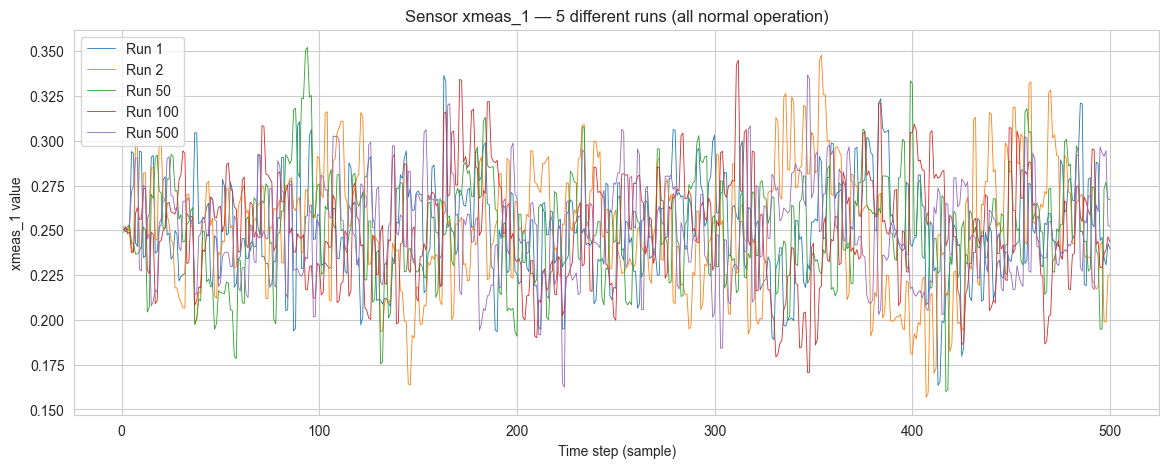

In [15]:
plt.figure(figsize=(14, 5))

for run_id in [1, 2, 50, 100, 500]:
    run_data = df[df['simulationRun'] == run_id]
    plt.plot(run_data['sample'], run_data['xmeas_1'], 
             linewidth=0.6, label=f'Run {run_id}', alpha=1.0)

plt.xlabel("Time step (sample)")
plt.ylabel("xmeas_1 value")
plt.title("Sensor xmeas_1 — 5 different runs (all normal operation)")
plt.legend()
plt.show()

What you should see: Five wiggly lines, all bouncing around the same center (~0.25) and within the same range (~0.17 to 0.34). They won't be identical — each run has different random noise.

Why this matters: This confirms that "normal" is consistent across runs. The plant always behaves roughly the same way under normal conditions. This is great news for the Isolation Forest — it means any run can serve as training data, and abnormal behavior will genuinely stand out.

In [16]:
stats = df.describe()
stats

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,250000.0,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,0.0,250.500000,250.500000,0.250482,3663.785706,4508.81979,9.347101,26.902196,42.337598,2705.037865,...,53.973668,24.639472,61.298501,22.216644,40.055456,38.098898,46.534295,47.958591,41.104304,18.118706
std,0.0,144.337567,144.337567,0.030873,34.006357,39.21542,0.085721,0.211485,0.218513,7.525596,...,0.469663,3.037743,1.243805,0.530156,1.526751,2.965266,2.351304,2.716520,0.540817,1.463678
min,0.0,1.000000,1.000000,0.122450,3511.800000,4336.90000,8.972700,25.951000,41.394000,2672.300000,...,52.095000,11.977000,55.961000,19.749000,33.389000,25.959000,36.937000,36.641000,38.586000,11.705000
25%,0.0,125.750000,125.750000,0.229770,3640.800000,4482.40000,9.289300,26.758000,42.188000,2700.100000,...,53.657000,22.602000,60.453000,21.864000,39.021000,36.081000,44.931000,46.265000,40.740000,17.130000
50%,0.0,250.500000,250.500000,0.250510,3663.700000,4508.80000,9.347100,26.902000,42.338000,2705.000000,...,53.974000,24.644000,61.298000,22.217000,40.058000,38.091000,46.530000,47.820000,41.104000,18.119000
75%,0.0,375.250000,375.250000,0.271200,3686.800000,4535.30000,9.405100,27.046000,42.487000,2710.000000,...,54.290000,26.674000,62.144000,22.568000,41.084000,40.117000,48.140000,49.651000,41.470000,19.111000
max,0.0,500.000000,500.000000,0.391740,3808.400000,4683.70000,9.729800,27.818000,43.257000,2739.100000,...,56.118000,38.351000,66.443000,24.525000,47.498000,50.729000,56.443000,59.616000,43.930000,24.762000


In [17]:
# Look at the first 6 measurement sensors
sensor_cols = ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6']
stats[sensor_cols].round(2)

,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6
count,250000.00,250000.00,250000.00,250000.00,250000.00,250000.00
mean,0.25,3663.79,4508.82,9.35,26.90,42.34
std,0.03,34.01,39.22,0.09,0.21,0.22
min,0.12,3511.80,4336.90,8.97,25.95,41.39
25%,0.23,3640.80,4482.40,9.29,26.76,42.19
50%,0.25,3663.70,4508.80,9.35,26.90,42.34
75%,0.27,3686.80,4535.30,9.41,27.05,42.49
max,0.39,3808.40,4683.70,9.73,27.82,43.26


Pay attention to the scale differences between sensors. xmeas_1 is around 0.25, but xmeas_2 is around 3664 and xmeas_7 is around 2700. These sensors measure completely different physical quantities at completely different scales.

Why this matters for the ML model: The Isolation Forest will see all 52 sensors at once. If we feed it raw values, xmeas_2 (range ~3600–3700) would dominate the model simply because its numbers are bigger, while xmeas_1 (range ~0.17–0.34) would be ignored. This is called the scale problem, and we'll solve it in Phase 3 by normalizing the data (scaling each sensor to have mean=0 and std=1).

-----------------------------------------------------------------------------------------------------------------------------------------------------
Meeting the Faulty Data:
- This is the most important chunk of the entire EDA. Everything until now was about "normal." Now we see what broken looks like

- What We're Doing and Why
We're loading the faulty training dataset, understanding its structure (how faults are organized), and then plotting a fault next to normal data so you can see the difference with your eyes. This is the moment that justifies every layer of the pipeline.

In [18]:
# Load the faulty Data
result_faulty = pyreadr.read_r('../data/TEP_Faulty_Training.rdata')
print(result_faulty.keys())

odict_keys(['faulty_training'])


In [19]:
df_faulty = result_faulty['faulty_training']
# Fix dtypes like we did before
df_faulty['simulationRun'] = df_faulty['simulationRun'].astype(int)
df_faulty['faultNumber'] = df_faulty['faultNumber'].astype(int)

print("Shape:", df_faulty.shape)
print("Memory:", round(df_faulty.memory_usage(deep=True).sum() / 1e6, 1), "MB")

Shape: (5000000, 55)
Memory: 2180.0 MB


In [20]:
print("Unique fault numbers:", sorted(df_faulty['faultNumber'].unique()))
print("\nRows per fault type:")
print(df_faulty['faultNumber'].value_counts().sort_index())

Unique fault numbers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]

Rows per fault type:
faultNumber
1     250000
2     250000
3     250000
4     250000
5     250000
6     250000
7     250000
8     250000
9     250000
10    250000
11    250000
12    250000
13    250000
14    250000
15    250000
16    250000
17    250000
18    250000
19    250000
20    250000
Name: count, dtype: int64


In [26]:
# GET ONE NORMAL RUN (from our fault-free data)
normal_run = df[df['simulationRun'] == 1]

# Get one faulty run (fault type 1, first run available)
fault1_data = df_faulty[df_faulty['faultNumber'] == 1]
fault1_run1 = fault1_data[fault1_data['simulationRun'] == fault1_data['simulationRun'].min()]

print("Normal run shape:", normal_run.shape)
print("Fault 1 run shape:", fault1_run1.shape)

Normal run shape: (500, 55)
Fault 1 run shape: (500, 55)


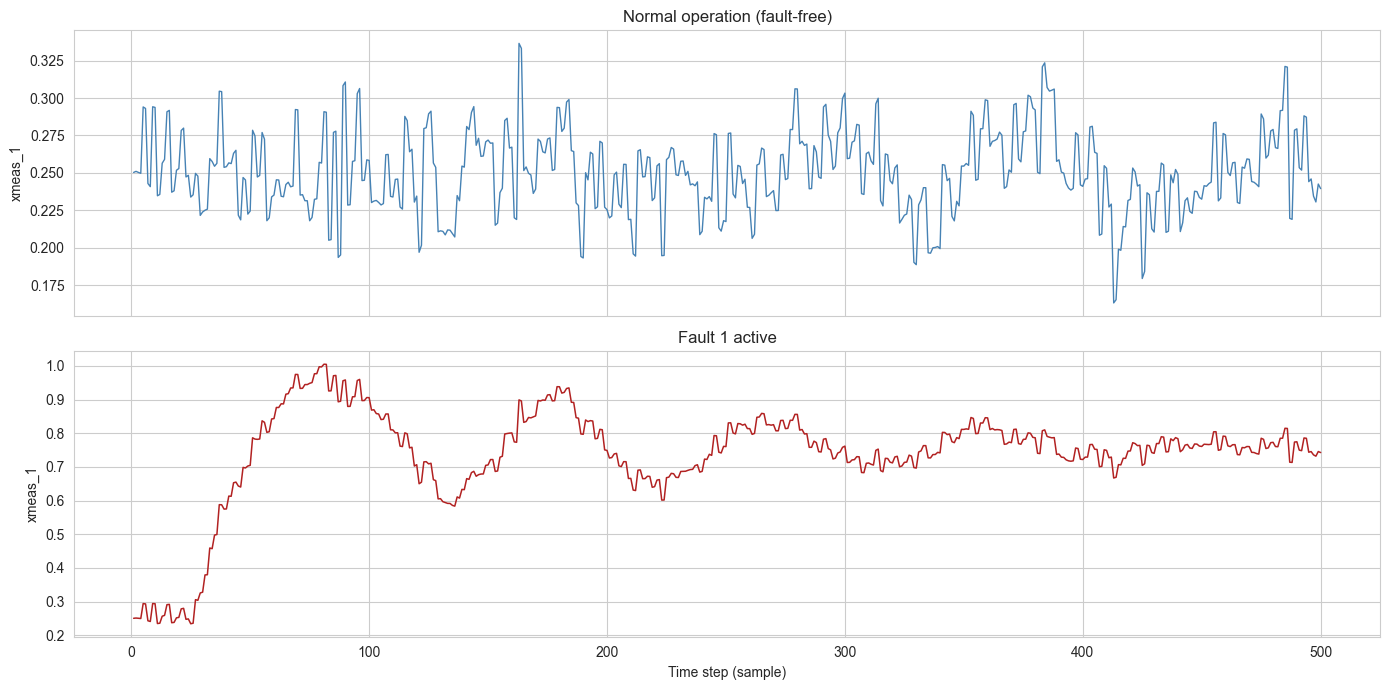

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top plot: normal
axes[0].plot(normal_run['sample'], normal_run['xmeas_1'], 
             linewidth=1., color='steelblue')
axes[0].set_ylabel("xmeas_1")
axes[0].set_title("Normal operation (fault-free)")

# Bottom plot: fault 1
axes[1].plot(fault1_run1['sample'], fault1_run1['xmeas_1'], 
             linewidth=1.1, color='firebrick')
axes[1].set_ylabel("xmeas_1")
axes[1].set_title("Fault 1 active")
axes[1].set_xlabel("Time step (sample)")

plt.tight_layout()
plt.show()

Look at the bottom plot carefully:

Samples 1–20: Normal. The red line sits around 0.25, wiggling just like the blue line above it. The plant is fine. The fault hasn't been injected yet.

Sample ~20: The fault activates. The line starts climbing. Not instantly — it ramps up over maybe 30 samples. By sample 60–80, xmeas_1 has shot from 0.25 all the way to 1.0 — that's a 4× increase in the A feed rate. The plant is now receiving way too much raw material A.

Samples 80–500: Oscillation. The value swings between roughly 0.6 and 1.0, never returning to the normal 0.25 range. The plant's control system is fighting the fault — trying to push the feed rate back down — but it can't fully correct it. Those waves are the control system and the fault wrestling each other.

This is Fault 1: a step change in the A/C feed ratio. Something suddenly changed in the composition of the input feed, and the plant is struggling to compensate.


Why This Matters for Each Layer of ChemStream
Connect this back to the architecture:
Faust (Layer 3): Remember, we said Faust would validate sensor ranges. Normal xmeas_1 lives in [0.17, 0.34].
The moment it hits 0.4, Faust would flag it. By the time it reaches 1.0, Faust has been screaming for dozens of messages.

Isolation Forest (Layer 3b): Even before xmeas_1 leaves the normal range, the model might detect the fault.
Why? Because when xmeas_1 starts climbing, other sensors change too — reactor pressure, temperatures,
compositions all shift together. The model sees all 52 sensors simultaneously and might catch the abnormal pattern even when individual values are still within bounds.
The dashboard (Layer 5): An operator looking at the blue chart (normal) would be bored. An operator looking at the red chart would immediately know something is wrong.
ChemStream's job is to make sure that red-chart moment gets surfaced as an alert within seconds, not discovered hours later during a shift change.

In [40]:
print("Rows per fault type:")
print(df_faulty['faultNumber'].value_counts().sort_index())
print("\nTotal faulty rows:", len(df_faulty))

Rows per fault type:
faultNumber
1     250000
2     250000
3     250000
4     250000
5     250000
6     250000
7     250000
8     250000
9     250000
10    250000
11    250000
12    250000
13    250000
14    250000
15    250000
16    250000
17    250000
18    250000
19    250000
20    250000
Name: count, dtype: int64

Total faulty rows: 5000000


What We're Doing and Why
We're asking: which sensors move together? If xmeas_1 goes up, does xmeas_4 also go up? Or does it go down? Or does it not care at all?
This matters for three practical reasons:

Dashboard design — if two sensors are 99% correlated (they always move together), showing both on the dashboard is redundant. We'd pick one.
Anomaly detection — the Isolation Forest detects broken relationships between sensors. If two sensors normally move together and suddenly one moves without the other, that's an anomaly. But we need to know the normal relationships first.
Debugging later — when a fault hits, you need to know which sensors to look at. The heatmap tells you which sensors are in the same "family."

In [42]:
# Select only the sensor columns (not metadata)
sensor_cols = [col for col in df.columns if col.startswith('xmeas') or col.startswith('xmv')]


print(f"Number of sensor columns: {len(sensor_cols)}")
sensor_cols

Number of sensor columns: 52


['xmeas_1',
 'xmeas_2',
 'xmeas_3',
 'xmeas_4',
 'xmeas_5',
 'xmeas_6',
 'xmeas_7',
 'xmeas_8',
 'xmeas_9',
 'xmeas_10',
 'xmeas_11',
 'xmeas_12',
 'xmeas_13',
 'xmeas_14',
 'xmeas_15',
 'xmeas_16',
 'xmeas_17',
 'xmeas_18',
 'xmeas_19',
 'xmeas_20',
 'xmeas_21',
 'xmeas_22',
 'xmeas_23',
 'xmeas_24',
 'xmeas_25',
 'xmeas_26',
 'xmeas_27',
 'xmeas_28',
 'xmeas_29',
 'xmeas_30',
 'xmeas_31',
 'xmeas_32',
 'xmeas_33',
 'xmeas_34',
 'xmeas_35',
 'xmeas_36',
 'xmeas_37',
 'xmeas_38',
 'xmeas_39',
 'xmeas_40',
 'xmeas_41',
 'xmv_1',
 'xmv_2',
 'xmv_3',
 'xmv_4',
 'xmv_5',
 'xmv_6',
 'xmv_7',
 'xmv_8',
 'xmv_9',
 'xmv_10',
 'xmv_11']

In [43]:
# Compute the correlation matrix
corr_matrix = df[sensor_cols].corr()

print("Correlation matrix shape:", corr_matrix.shape)

Correlation matrix shape: (52, 52)


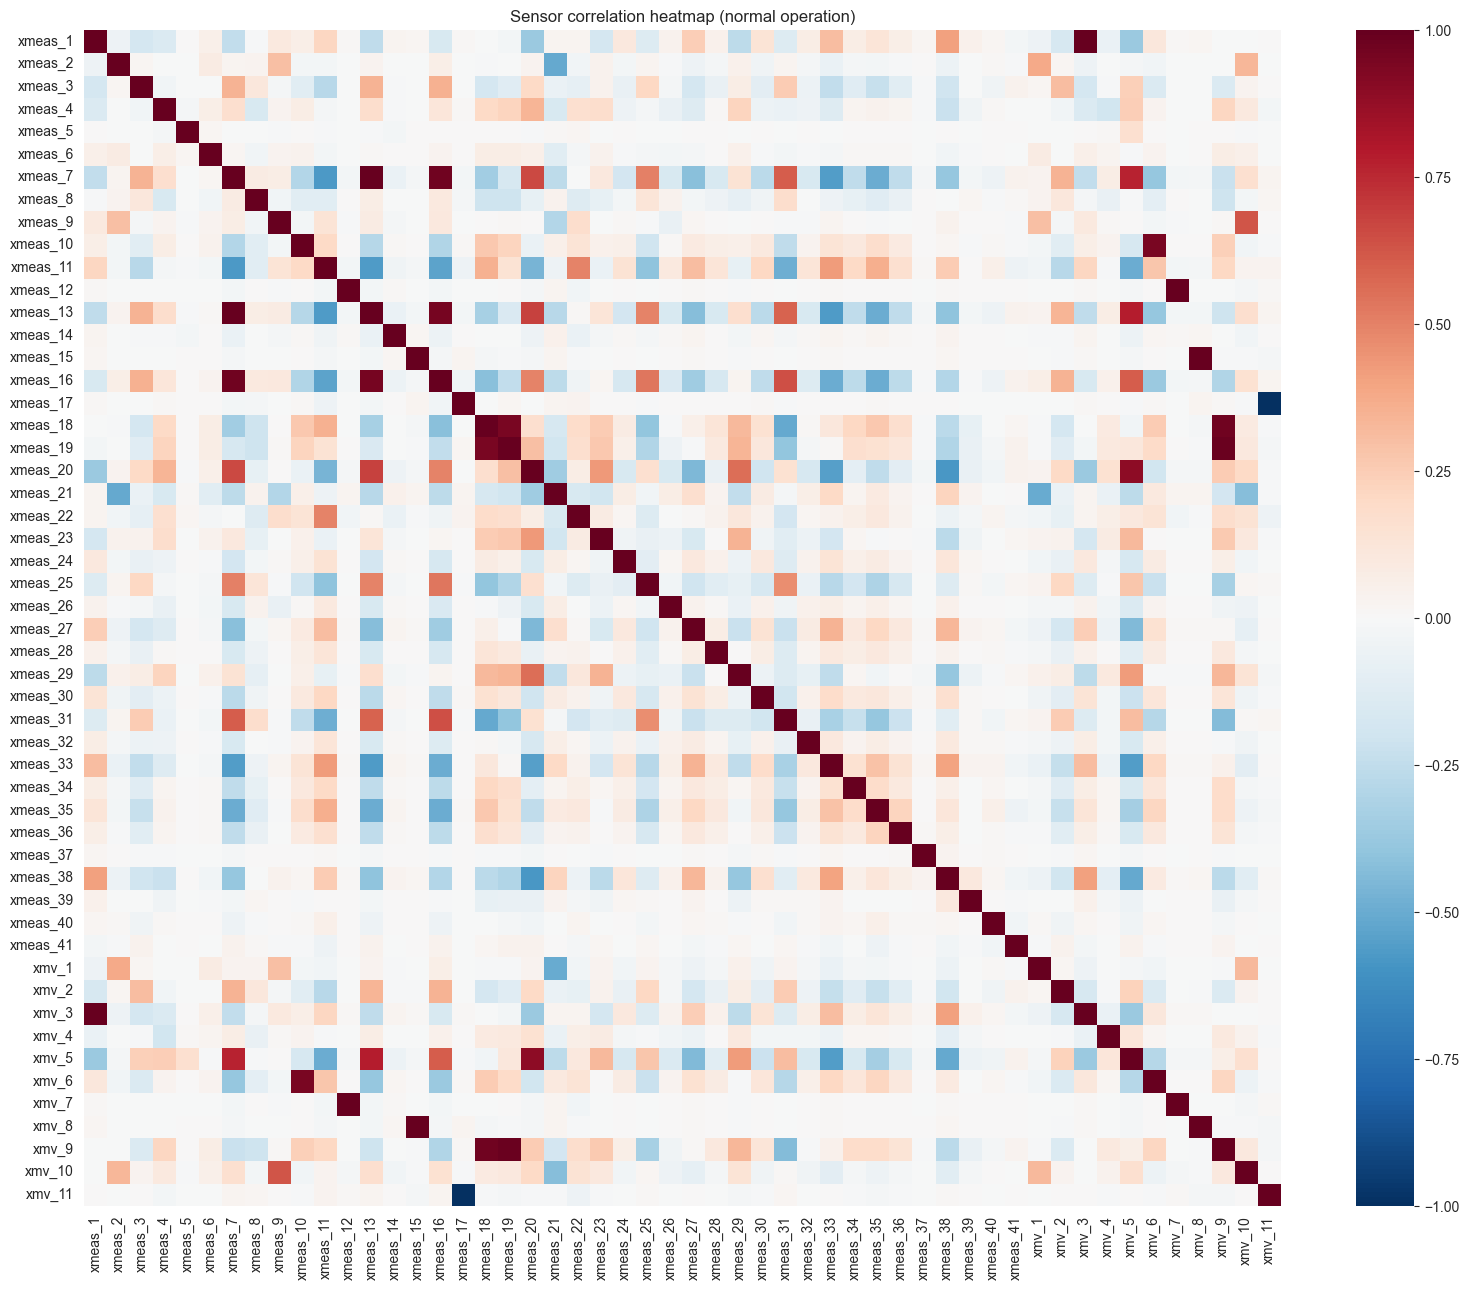

In [44]:
plt.figure(figsize=(16, 13))

sns.heatmap(corr_matrix, 
            cmap='RdBu_r',
            vmin=-1, 
            vmax=1, 
            center=0,
            xticklabels=True,
            yticklabels=True)

plt.title("Sensor correlation heatmap (normal operation)")
plt.tight_layout()
plt.show()

Let's confirm the correlation cluster with a concrete example. Pick two sensors that look strongly correlated on the heatmap and plot them against each other. New cell:

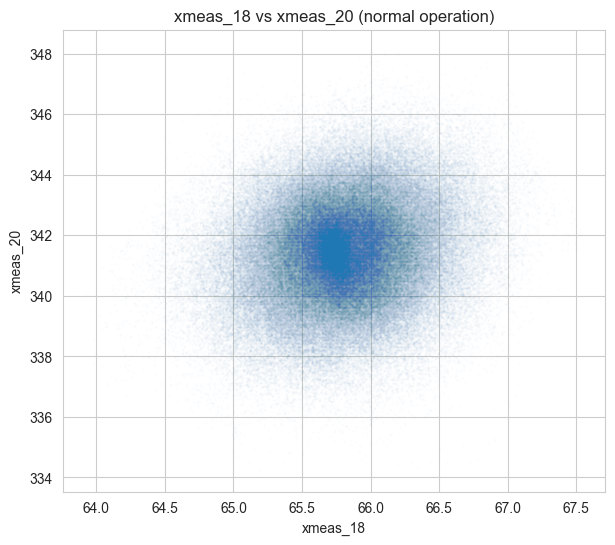

In [45]:
plt.figure(figsize=(7, 6))
plt.scatter(df['xmeas_18'], df['xmeas_20'], 
            alpha=0.01, s=1)
plt.xlabel("xmeas_18")
plt.ylabel("xmeas_20")
plt.title("xmeas_18 vs xmeas_20 (normal operation)")
plt.show()

In [46]:
print("Correlation:", df['xmeas_18'].corr(df['xmeas_20']).round(3))

Correlation: 0.168


## EDA Findings — TEP Dataset

### Dataset structure
- **Fault-free training:** 250,000 rows (500 runs × 500 samples)
- **Faulty training:** 5,000,000 rows (20 fault types × 500 runs × 500 samples)
- **Columns:** 55 total — 3 metadata + 41 measurements + 11 valve positions
- **Nulls:** zero across all columns
- **Sample interval:** 3 simulated minutes per time step

### Normal operating behavior
- Sensors fluctuate randomly around stable center values
- No trends or drift in fault-free data
- Behavior is consistent across all 500 runs

### Key sensor ranges (fault-free)
- xmeas_1 (A feed): ~0.17 to 0.34, center ~0.25
- Sensors vary enormously in scale (0.25 vs 3664 vs 2700)
- Normalization will be required before ML training

### Fault characteristics
- 20 fault types, all balanced (250k rows each)
- Faults injected at sample 20 in training data
- Fault 1 (step change): dramatic 4× increase visible in xmeas_1
- Some faults are subtle (slow drifts), others are obvious (step changes)

### Correlation structure
- Most sensor pairs are weakly correlated or uncorrelated
- Composition sensors (xmeas_18-26) form a moderate cluster
- Control valves (xmv) show negative correlation with some measurements (feedback loops)
- Heatmap colors can be misleading — always verify with actual numbers

In [48]:
# Extract one run for the producer to stream
run1 = df[df['simulationRun'] == 1].copy()

# Drop metadata columns the producer doesn't need to stream
# Keep faultNumber because the dashboard will use it for coloring
run1_clean = run1.drop(columns=['simulationRun'])

print("Export shape:", run1_clean.shape)
print("Columns:", list(run1_clean.columns[:5]), "...", list(run1_clean.columns[-3:]))

# Save to CSV
run1_clean.to_csv('../data/run1_normal.csv', index=False)
print("\nSaved to data/run1_normal.csv")

Export shape: (500, 54)
Columns: ['faultNumber', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3'] ... ['xmv_9', 'xmv_10', 'xmv_11']

Saved to data/run1_normal.csv


In [49]:
# Export one faulty run (fault 1, first run) for later testing
fault1_data = df_faulty[df_faulty['faultNumber'] == 1]
fault1_run = fault1_data[fault1_data['simulationRun'] == fault1_data['simulationRun'].min()].copy()
fault1_run = fault1_run.drop(columns=['simulationRun'])

fault1_run.to_csv('../data/run1_fault1.csv', index=False)
print("Saved to data/run1_fault1.csv")
print("Shape:", fault1_run.shape)

Saved to data/run1_fault1.csv
Shape: (500, 54)


In [50]:
# Quick sanity check — read them back and confirm
import os

for filename in ['run1_normal.csv', 'run1_fault1.csv']:
    filepath = f'../data/{filename}'
    size_kb = os.path.getsize(filepath) / 1024
    test_df = pd.read_csv(filepath)
    print(f"{filename}: {test_df.shape[0]} rows, {test_df.shape[1]} cols, {size_kb:.0f} KB")

run1_normal.csv: 500 rows, 54 cols, 182 KB
run1_fault1.csv: 500 rows, 54 cols, 182 KB
